# VGG-16 — autoLRP attribution

VGG-16 from torchvision (ImageNet weights). One forward pass, one `out[0, pred].lrp()` call, one heatmap; the composite recipe is z+ on the convolutions and epsilon on the classifier.

In [1]:
import sys
sys.path.insert(0, '..')          # examples/showcase: _common
sys.path.insert(0, '../../..')    # repo root: autoLRP (or `pip install -e .`)
import torch
from torchvision.models import vgg16, VGG16_Weights

import autoLRP as autolrp
from autoLRP import LRPConfig, BASE
from _common import load_showcase_images, show_vision_attribution, show_vision_comparison, imagenet_classes

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
model = vgg16(weights=VGG16_Weights.DEFAULT).eval().to(device)
images = load_showcase_images(device=device)
print(f'Loaded {len(images)} showcase images')

Loaded 1 showcase images


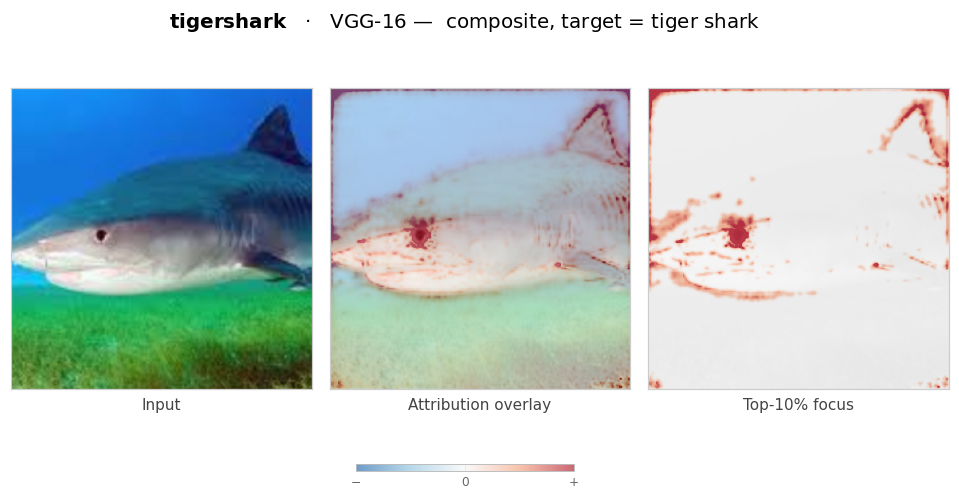

In [3]:
for img, label in images:
    with torch.no_grad():
        pred = model(img).argmax(-1).item()
    pred_name = imagenet_classes()[pred]

    x = autolrp.tensor(img.clone())
    model(x)[0, pred].lrp(config=LRPConfig.composite())

    show_vision_attribution(
        img, 
        x.relevance, 
        pred_label=pred_name,
        rule_name=f'VGG-16 —  composite, target = {pred_name.lower()}'
    )

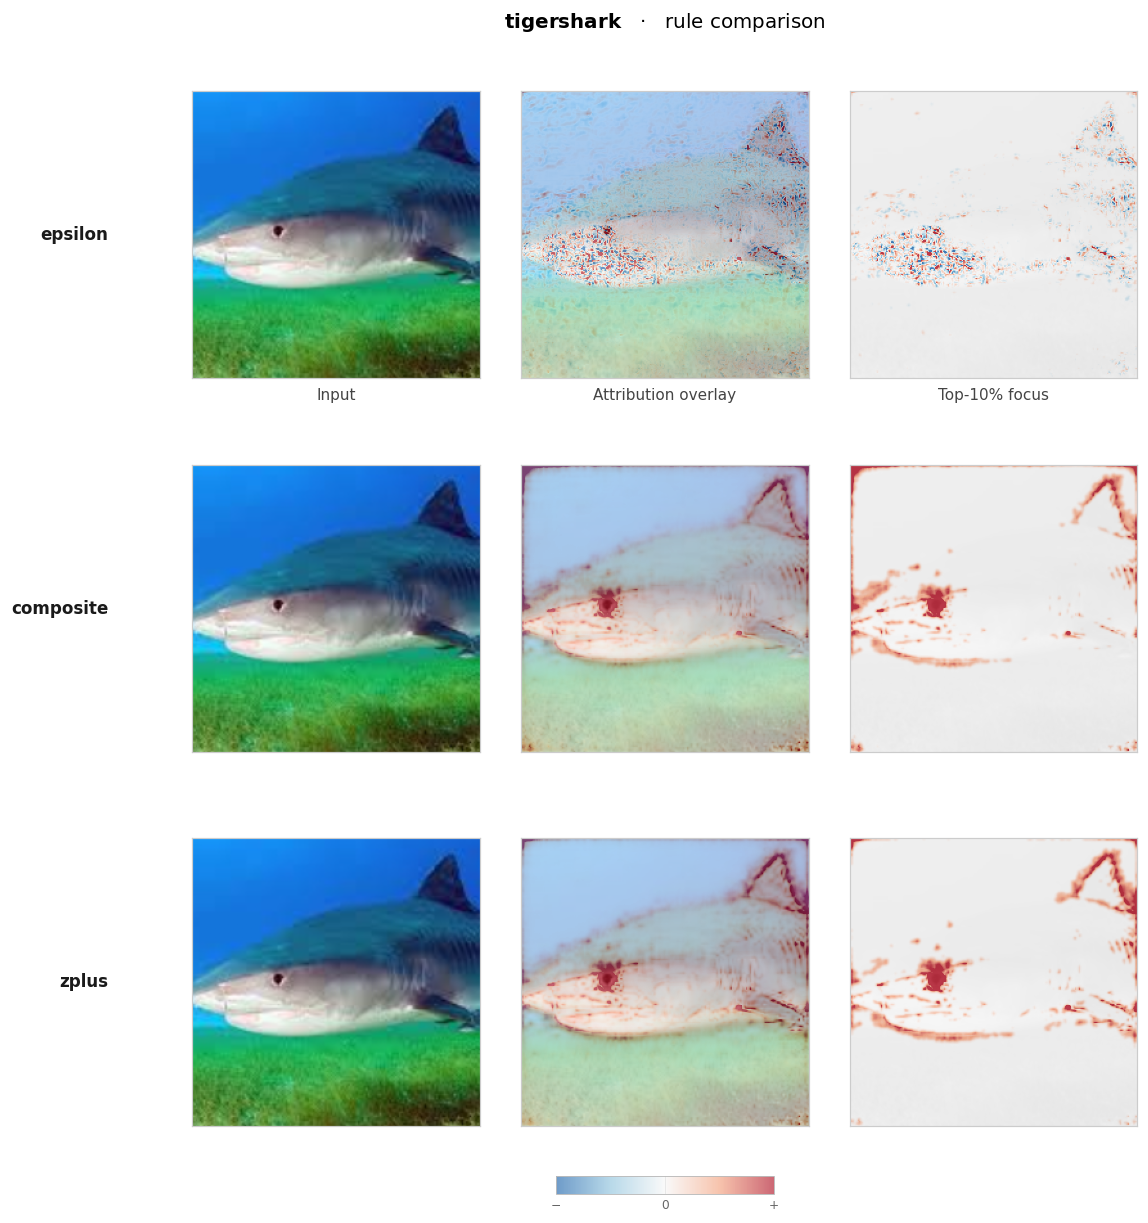

In [4]:
# Side-by-side rule comparison on the first showcase image.
img, label = images[0]
with torch.no_grad():
    pred = model(img).argmax(-1).item()
pred_name = imagenet_classes()[pred]

# Three configs: BASE (epsilon on every linear family), the composite recipe
# (z+ on conv, epsilon on the classifier), and z+ on conv and classifier alike.
configs = [
    ('epsilon',   LRPConfig()),
    ('composite', LRPConfig.composite()),
    ('zplus',     LRPConfig(rule={**BASE, 'ConvolutionBackward': 'zplus', 'AddmmBackward': 'zplus'})),
]
rule_results = []
for name, cfg in configs:
    x = autolrp.tensor(img.clone())
    model(x)[0, pred].lrp(config=cfg)
    rule_results.append((name, x.relevance))

show_vision_comparison(img, rule_results, pred_label=pred_name)